# Exploración inicial — Predicción de retraso de vuelos (NYC, 2013)

**Proyecto final de curso: Machine Learning**
**Dataset:** `nycflights13` — vuelos que salieron de los tres aeropuertos de
Nueva York (JFK, LGA, EWR) durante 2013, junto con clima horario, información
de aeronaves, aerolíneas y aeropuertos de destino.

**Pregunta predictiva:** dado un vuelo *antes de que despegue*, ¿llegará con
un retraso de 15 minutos o más respecto a su horario programado?

Este notebook cubre los requisitos mínimos de la entrega previa:
carga de datos, dimensiones y tipos, % de valores faltantes, distribución del
target, ≥5 visualizaciones, detección de outliers, discusión de leakage/sesgos
y un primer baseline honesto.


## 1. Carga de datos

El dataset se instala como paquete de Python (`pip install nycflights13`), por lo que la carga es 100% reproducible sin descargas externas ni credenciales. Unimos 5 tablas relacionales: `flights`, `weather`, `planes`, `airports`, `airlines` (ver `src/data.py`).

In [1]:
import sys
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from data import build_dataset, load_raw, feature_columns, TARGET_COL, LEAKAGE_COLS

raw = load_raw()
for name, tbl in raw.items():
    print(f"{name:10s} -> {tbl.shape}")


flights    -> (336776, 19)
weather    -> (26115, 15)
planes     -> (3322, 9)
airports   -> (1458, 8)
airlines   -> (16, 2)


In [2]:
df = build_dataset()
print("Dataset final (tras uniones):", df.shape)
df.head(3)


Dataset final (tras uniones): (327346, 39)


,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,...,wind_dir,wind_speed,wind_gust,precip,pressure,visib,name,dest_lat,dest_lon,dest_alt
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,...,260.0,12.65858,NaN,0.0,1011.9,10.0,United Air Lines Inc.,29.984433,-95.341442,97.0
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,...,250.0,14.96014,21.86482,0.0,1011.4,10.0,United Air Lines Inc.,29.984433,-95.341442,97.0
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,...,260.0,14.96014,NaN,0.0,1012.1,10.0,American Airlines Inc.,25.793250,-80.290556,8.0


## 2. Filas, columnas y tipos de datos

In [3]:
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print()
print(df.dtypes.value_counts())
print()
df.dtypes


Filas: 327,346
Columnas: 39

float64                20
int64                  10
str                     8
datetime64[us, UTC]     1
Name: count, dtype: int64



year                            int64
month                           int64
day                             int64
dep_time                      float64
sched_dep_time                  int64
dep_delay                     float64
arr_time                      float64
sched_arr_time                  int64
arr_delay                     float64
carrier                           str
flight                          int64
tailnum                           str
origin                            str
dest                              str
air_time                      float64
distance                        int64
hour                            int64
minute                          int64
time_hour         datetime64[us, UTC]
retraso_15                      int64
plane_year                    float64
manufacturer                      str
model                             str
engines                       float64
seats                         float64
engine                            str
temp        

**Nota sobre tamaño real:** el dataset unido tiene más de 327 mil vuelos y 39 columnas combinando información de vuelo, clima, aeronave, aerolínea y aeropuerto — muy por encima del umbral de 50,000 filas pedido para datasets propuestos, y con múltiples tablas relacionales, lo cual añade dificultad real de limpieza y de control de fugas de información (leakage).

## 3. Porcentaje de valores faltantes por variable

In [4]:
miss = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
miss = miss[miss > 0]
miss


wind_gust       76.34
plane_year      16.34
engines         14.76
manufacturer    14.76
model           14.76
engine          14.76
seats           14.76
pressure        11.04
wind_dir         2.92
dest_lon         2.30
dest_lat         2.30
dest_alt         2.30
wind_speed       0.49
humid            0.47
temp             0.47
visib            0.47
precip           0.47
dewp             0.47
dtype: float64

**Lectura:** `wind_gust` falta en ~76% de los registros (muchas estaciones no reportan racha de viento) — se descarta como feature. Las columnas de aeronave (`plane_year`, `manufacturer`, `model`, `engines`, `seats`, `engine`) faltan en ~15-16% porque algunos `tailnum` no están en el catálogo de aviones (aeronaves dadas de baja o mal registradas). El resto de variables de clima falta <3%. Ninguna de estas ausencias es aleatoria pura: hay que imputarlas con cuidado y documentar la limitación, no simplemente eliminarlas.

## 4. Variable objetivo: distribución

In [5]:
print(df[TARGET_COL].value_counts())
print()
print((df[TARGET_COL].value_counts(normalize=True) * 100).round(1), "%")


retraso_15
0    247246
1     80100
Name: count, dtype: int64

retraso_15
0    75.5
1    24.5
Name: proportion, dtype: float64 %


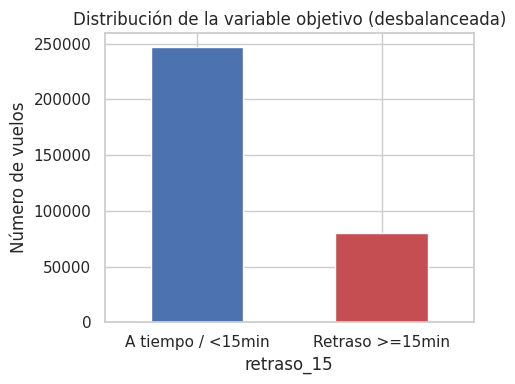

In [6]:
fig, ax = plt.subplots(figsize=(5,4))
df[TARGET_COL].value_counts().sort_index().plot(kind='bar', color=['#4C72B0','#C44E52'], ax=ax)
ax.set_xticklabels(['A tiempo / <15min', 'Retraso >=15min'], rotation=0)
ax.set_title('Distribución de la variable objetivo (desbalanceada)')
ax.set_ylabel('Número de vuelos')
plt.tight_layout()
plt.show()


**Desbalance real:** ~75.5% de los vuelos llegan a tiempo (o con menos de 15 min de retraso) y ~24.5% se consideran retrasados. Esto es suficientemente desbalanceado como para que **reportar solo accuracy sea engañoso** (un modelo que siempre predice "a tiempo" ya tendría ~75-82% de accuracy sin ser útil). Se reportará precision, recall, F1 y ROC-AUC además de accuracy.

## 5. Distribución de la variable continua subyacente (`arr_delay`)

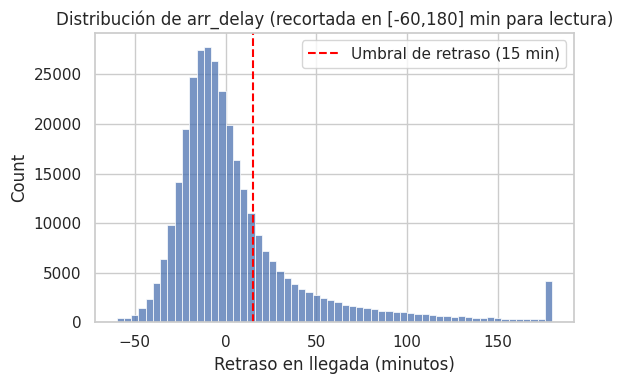

In [7]:
flights_full = raw['flights']
delay_clip = flights_full['arr_delay'].clip(-60, 180)

fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(delay_clip.dropna(), bins=60, ax=ax, color='#4C72B0')
ax.axvline(15, color='red', linestyle='--', label='Umbral de retraso (15 min)')
ax.set_title('Distribución de arr_delay (recortada en [-60,180] min para lectura)')
ax.set_xlabel('Retraso en llegada (minutos)')
ax.legend()
plt.tight_layout()
plt.show()


La mayoría de vuelos llega antes o poco después de lo programado; la cola derecha (retrasos grandes) es larga, típica de fenómenos climáticos o logísticos puntuales.

## 6. Outliers y registros sospechosos

In [8]:
print(flights_full['arr_delay'].describe())
print()
extreme = flights_full[flights_full['arr_delay'] > 500]
print(f"Vuelos con retraso > 500 min (>8h): {len(extreme)} ({len(extreme)/len(flights_full)*100:.3f}% del total)")
extreme[['month','day','carrier','origin','dest','dep_delay','arr_delay']].sort_values('arr_delay', ascending=False).head(10)


count    327346.000000
mean          6.895377
std          44.633292
min         -86.000000
25%         -17.000000
50%          -5.000000
75%          14.000000
max        1272.000000
Name: arr_delay, dtype: float64

Vuelos con retraso > 500 min (>8h): 51 (0.015% del total)


,month,day,carrier,origin,dest,dep_delay,arr_delay
7072,1,9,HA,JFK,HNL,1301.0,1272.0
235778,6,15,MQ,JFK,CMH,1137.0,1127.0
8239,1,10,MQ,EWR,ORD,1126.0,1109.0
327043,9,20,AA,JFK,SFO,1014.0,1007.0
270376,7,22,MQ,JFK,CVG,1005.0,989.0
173992,4,10,DL,JFK,TPA,960.0,931.0
151974,3,17,DL,LGA,MSP,911.0,915.0
270987,7,22,DL,LGA,ATL,898.0,895.0
87238,12,5,AA,EWR,MIA,896.0,878.0
195711,5,3,MQ,EWR,ORD,878.0,875.0


**Outliers identificados:** hay 51 vuelos (0.015%) con más de 8 horas de retraso — probablemente cancelaciones parciales, desvíos o eventos climáticos extremos (nevadas, huracanes). No se eliminan de plano: se documentan como cola realista del fenómeno, y se revisará su impacto en modelos sensibles a outliers (regresión lineal) vs. robustos (árboles).

**Registros sospechosos adicionales:** 9,430 vuelos (2.8%) fueron **cancelados** (`arr_delay` es NaN porque el vuelo nunca llegó). Estos se excluyen del target de retraso, pero representan una limitación real: un sistema en producción también debería predecir la *probabilidad de cancelación*, un problema relacionado pero distinto que queda fuera del alcance de este proyecto (se documenta como trabajo futuro).

## 7. Retraso por mes (estacionalidad)

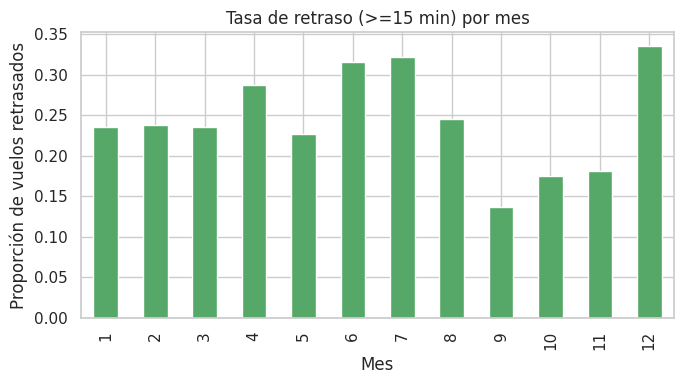

In [9]:
tasa_mes = df.groupby('month')[TARGET_COL].mean()
fig, ax = plt.subplots(figsize=(7,4))
tasa_mes.plot(kind='bar', color='#55A868', ax=ax)
ax.set_title('Tasa de retraso (>=15 min) por mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Proporción de vuelos retrasados')
plt.tight_layout()
plt.show()


Diciembre y junio-julio muestran las tasas más altas de retraso (temporada de invierno/nieve y temporada alta de verano), consistente con lo esperado por clima y congestión.

## 8. Retraso por aerolínea

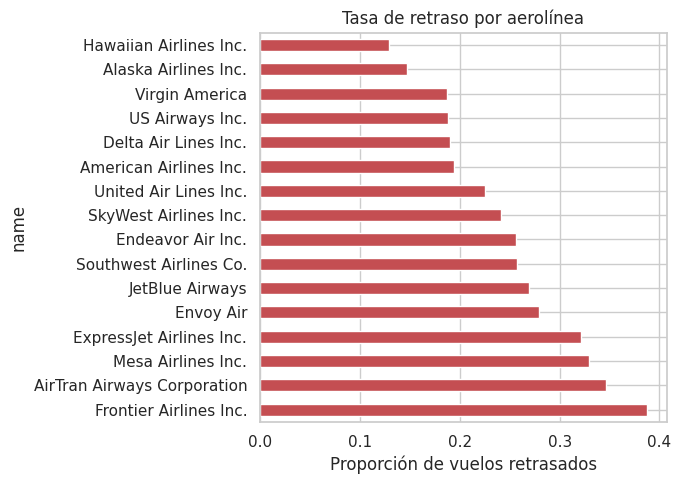

In [10]:
tasa_carrier = df.groupby('name')[TARGET_COL].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,5))
tasa_carrier.plot(kind='barh', color='#C44E52', ax=ax)
ax.set_title('Tasa de retraso por aerolínea')
ax.set_xlabel('Proporción de vuelos retrasados')
plt.tight_layout()
plt.show()


Hay diferencias notables entre aerolíneas (hasta 2-3x entre la mejor y la peor), lo que sugiere que `carrier` será una variable relevante — aunque puede confundirse con la ruta/aeropuerto que opera cada aerolínea (variable de confusión a tener en cuenta).

## 9. Retraso por hora programada de salida

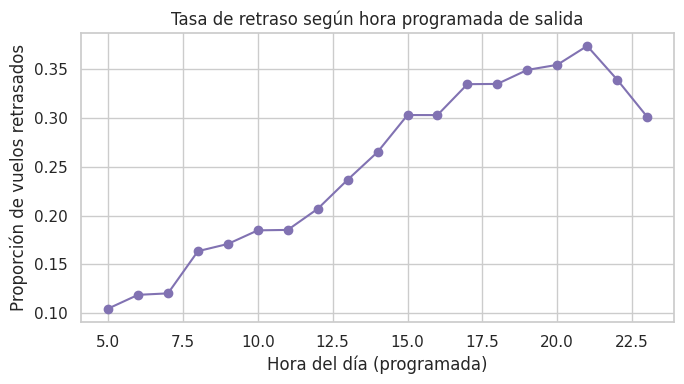

In [11]:
tasa_hora = df.groupby('hour')[TARGET_COL].mean()
fig, ax = plt.subplots(figsize=(7,4))
tasa_hora.plot(kind='line', marker='o', color='#8172B2', ax=ax)
ax.set_title('Tasa de retraso según hora programada de salida')
ax.set_xlabel('Hora del día (programada)')
ax.set_ylabel('Proporción de vuelos retrasados')
plt.tight_layout()
plt.show()


Los retrasos se acumulan durante el día: los vuelos de la mañana temprano tienen la menor tasa de retraso y esta crece hacia la noche — patrón clásico de "efecto cascada" (un avión retrasado retrasa sus siguientes vuelos). **Importante:** esto no lo podemos usar como feature causal ingenuo, porque en producción real solo tendríamos la hora *programada*, no el retraso acumulado del día (que sería leakage).

## 10. Correlación entre clima/distancia y retraso

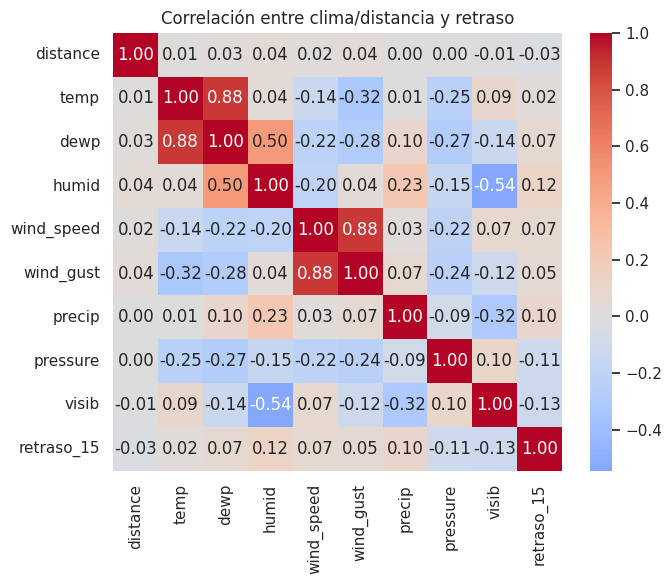

In [12]:
num_cols = ['distance','temp','dewp','humid','wind_speed','wind_gust','precip','pressure','visib']
corr_df = df[num_cols + [TARGET_COL]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlación entre clima/distancia y retraso')
plt.tight_layout()
plt.show()


Las correlaciones lineales individuales con el target son débiles (como es típico en variables climáticas vs. una variable binaria) — esto ya anticipa que un baseline lineal simple tendrá poder predictivo limitado, y que interacciones (ej. viento + visibilidad + aeropuerto) probablemente importan más que el efecto marginal de cada variable por separado.

## 11. Riesgos de leakage identificados

Para que el modelo sea útil (predecir *antes* de que el vuelo despegue), se
**excluyen explícitamente** estas columnas de los features, aunque estén en
el dataset, porque solo se conocen durante o después del vuelo:

| Columna | Por qué es leakage |
|---|---|
| `dep_time` | Hora real de salida — no se conoce hasta que el avión despega |
| `dep_delay` | Retraso real de salida — casi determina el retraso de llegada |
| `arr_time` | Hora real de llegada — es prácticamente el target |
| `air_time` | Duración real del vuelo — solo se conoce al aterrizar |
| `arr_delay` | Es la variable con la que se construye el target |

Un error común (y penalizado en la rúbrica) sería incluir `dep_delay` como
feature: como está fuertemente correlacionado con `arr_delay`, daría una
métrica artificialmente alta pero inútil en producción, porque al momento de
predecir (antes del despegue) todavía no existe.


In [13]:
print("Columnas excluidas por leakage temporal:")
for c in LEAKAGE_COLS:
    print(" -", c)
print()
print(f"Features disponibles ANTES del despegue: {len(feature_columns(df))}")
feature_columns(df)


Columnas excluidas por leakage temporal:
 - dep_time
 - dep_delay
 - arr_time
 - air_time
 - arr_delay

Features disponibles ANTES del despegue: 28


['month',
 'day',
 'sched_dep_time',
 'sched_arr_time',
 'carrier',
 'origin',
 'dest',
 'distance',
 'hour',
 'minute',
 'plane_year',
 'manufacturer',
 'model',
 'engines',
 'seats',
 'engine',
 'temp',
 'dewp',
 'humid',
 'wind_dir',
 'wind_speed',
 'wind_gust',
 'precip',
 'pressure',
 'visib',
 'dest_lat',
 'dest_lon',
 'dest_alt']

## 12. Sesgos y limitaciones (discusión inicial)

- **Sesgo geográfico:** el dataset cubre solo vuelos que *salen* de Nueva York
  en 2013. No generaliza a otros aeropuertos, aerolíneas fuera de ese mercado,
  ni a años posteriores (cambios en flota, rutas, clima).
- **Vuelos cancelados excluidos:** al quitar los 9,430 vuelos cancelados del
  target de retraso, el modelo aprende solo sobre vuelos que sí operaron —
  un sesgo de selección real que debe declararse (en la práctica, un vuelo
  cancelado es "más grave" que uno retrasado, y el sistema debería tratarlo
  aparte).
- **Clima como "oráculo":** usamos el clima *observado* en la hora del vuelo,
  no un *pronóstico*. En producción real solo se tendría un pronóstico (con
  error), así que el desempeño reportado aquí es optimista respecto a un
  sistema desplegado en el mundo real. Se documentará como limitación en el
  informe final.
- **Matching imperfecto:** ~16% de los vuelos no tienen match en la tabla de
  aviones (`tailnum` no encontrado) — se imputa como faltante, pero podría
  introducir un sesgo si esos aviones son sistemáticamente distintos (p. ej.
  aeronaves más viejas o de aerolíneas específicas).


## 13. Primer baseline (simple y honesto)

Modelo baseline pedido para clasificación: **regresión logística**, comparado contra un baseline "tonto" que siempre predice la clase mayoritaria (para dejar en evidencia por qué el accuracy solo no basta).

### Plan de validación: split temporal (no aleatorio)

Los vuelos tienen estructura temporal (clima, temporada, tráfico). Un split aleatorio 80/20 filtraría información del "futuro" hacia el "pasado" (ej. patrones de una tormenta de diciembre aparecerían en train y test simultáneamente). En su lugar:

- **Train:** enero–octubre 2013
- **Validación:** noviembre 2013
- **Test (solo lectura final):** diciembre 2013

Esto imita cómo se usaría el modelo en producción: entrenar con el pasado, predecir el futuro.

In [14]:
train_df = df[df['month'] <= 10].copy()
val_df   = df[df['month'] == 11].copy()
test_df  = df[df['month'] == 12].copy()

print(f"Train (ene-oct): {train_df.shape[0]:,} vuelos")
print(f"Val   (nov):     {val_df.shape[0]:,} vuelos")
print(f"Test  (dic):     {test_df.shape[0]:,} vuelos")


Train (ene-oct): 273,355 vuelos
Val   (nov):     26,971 vuelos
Test  (dic):     27,020 vuelos


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)

feat_num = ['sched_dep_time','sched_arr_time','distance','plane_year','seats',
            'temp','dewp','humid','wind_speed','precip','pressure','visib']
feat_cat = ['month','carrier','origin','dest','engine']

X_train, y_train = train_df[feat_num+feat_cat], train_df[TARGET_COL]
X_val, y_val     = val_df[feat_num+feat_cat],   val_df[TARGET_COL]
X_test, y_test   = test_df[feat_num+feat_cat],  test_df[TARGET_COL]

pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), feat_num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                       ('ohe', OneHotEncoder(handle_unknown='ignore'))]), feat_cat),
])

dummy = Pipeline([('pre', pre), ('clf', DummyClassifier(strategy='most_frequent'))])
dummy.fit(X_train, y_train)

logreg = Pipeline([('pre', pre), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))])
logreg.fit(X_train, y_train)
print("Modelos entrenados.")


Modelos entrenados.


In [16]:
def evaluate(model, X, y, name):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:,1]
    res = {
        'accuracy': accuracy_score(y,pred),
        'precision': precision_score(y,pred),
        'recall': recall_score(y,pred),
        'f1': f1_score(y,pred),
        'roc_auc': roc_auc_score(y,proba),
    }
    print(f"--- {name} ---")
    for k,v in res.items():
        print(f"{k:10s}: {v:.3f}")
    print()
    return res

print("===== VALIDACIÓN (noviembre) =====\n")
m_dummy = evaluate(dummy, X_val, y_val, "Dummy (siempre 'a tiempo')")
m_log   = evaluate(logreg, X_val, y_val, "Regresión logística (baseline)")


===== VALIDACIÓN (noviembre) =====

--- Dummy (siempre 'a tiempo') ---
accuracy  : 0.819
precision : 0.000
recall    : 0.000
f1        : 0.000
roc_auc   : 0.500



--- Regresión logística (baseline) ---
accuracy  : 0.671
precision : 0.291
recall    : 0.568
f1        : 0.385
roc_auc   : 0.673



**Lectura honesta del resultado:** el modelo *dummy* logra ~82% de accuracy simplemente por el desbalance de clases, pero su F1 y recall son **0** — no detecta ni un solo vuelo retrasado, es inútil. La regresión logística tiene *menor* accuracy (~67%) pero F1 real (~0.38) y ROC-AUC de ~0.67, es decir, sí aprende una señal útil aunque limitada. Esto confirma por qué la consigna penaliza reportar solo accuracy en un problema desbalanceado: por sí sola, esa métrica habría hecho ver al modelo *tonto* como "mejor".

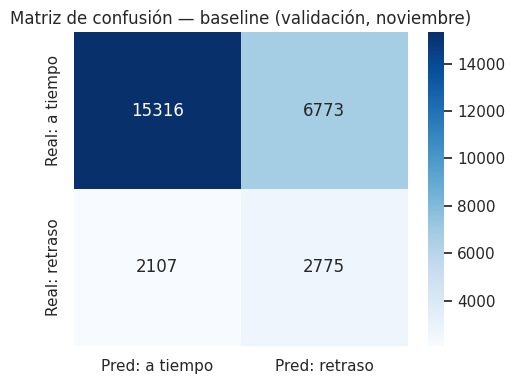

In [17]:
pred_val = logreg.predict(X_val)
cm = confusion_matrix(y_val, pred_val)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred: a tiempo','Pred: retraso'],
            yticklabels=['Real: a tiempo','Real: retraso'])
ax.set_title('Matriz de confusión — baseline (validación, noviembre)')
plt.tight_layout()
plt.show()


In [18]:
print("===== TEST (diciembre) — solo lectura final, no se usó para ajustar nada =====\n")
m_dummy_test = evaluate(dummy, X_test, y_test, "Dummy — TEST")
m_log_test   = evaluate(logreg, X_test, y_test, "Regresión logística — TEST")


===== TEST (diciembre) — solo lectura final, no se usó para ajustar nada =====



--- Dummy — TEST ---
accuracy  : 0.665
precision : 0.000
recall    : 0.000
f1        : 0.000
roc_auc   : 0.500



--- Regresión logística — TEST ---
accuracy  : 0.644
precision : 0.477
recall    : 0.659
f1        : 0.553
roc_auc   : 0.702



El desempeño en test (diciembre) es consistente con validación (misma brecha dummy vs. logística), lo cual es una señal saludable: el modelo no está sobreajustado a noviembre específicamente. Diciembre tiene una tasa base de retraso más alta (clima invernal), lo que explica que el accuracy del dummy baje a ~66% ahí.

## 14. Próximos pasos (semanas restantes)

1. Ingeniería de features: interacción clima×aeropuerto, antigüedad de la
   aeronave, franjas horarias, codificación de alta cardinalidad para `dest`.
2. Probar modelos no lineales (Random Forest, Gradient Boosting) y comparar
   contra este baseline con las mismas métricas y el mismo split temporal.
3. Análisis de errores por segmento (aeropuerto de origen, aerolínea, mes).
4. Calibración de probabilidades e interpretabilidad (SHAP o coeficientes).
5. Documentar limitaciones finales (clima real vs. pronóstico, vuelos
   cancelados) en el informe final.
